# PS: P-Spline with IWLS proposals and score-squared weights

## Setup and Imports

In [1]:
import jax.numpy as jnp
import liesel.goose as gs
import liesel.model as lsl
import numpy as np
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel_gam as gam
from liesel_gam.iwls_proposals import IWLSProposal, IWLSWeights


Warning message:
package ‘arrow’ was built under R version 4.5.2 


In [2]:
from scipy import stats

rng = np.random.default_rng(1)
x = rng.uniform(-2, 2, 200)

log_sigma = -1.0 + 0.3 * (
    0.5 * x + 15 * stats.norm.pdf(2 * (x - 0.2)) - stats.norm.pdf(x + 0.4)
)
mu = -x + np.pi * np.sin(np.pi * x)
y = mu + jnp.exp(log_sigma) * rng.normal(0.0, 1.0, 200)

df = pd.DataFrame({"y": y, "x": x})

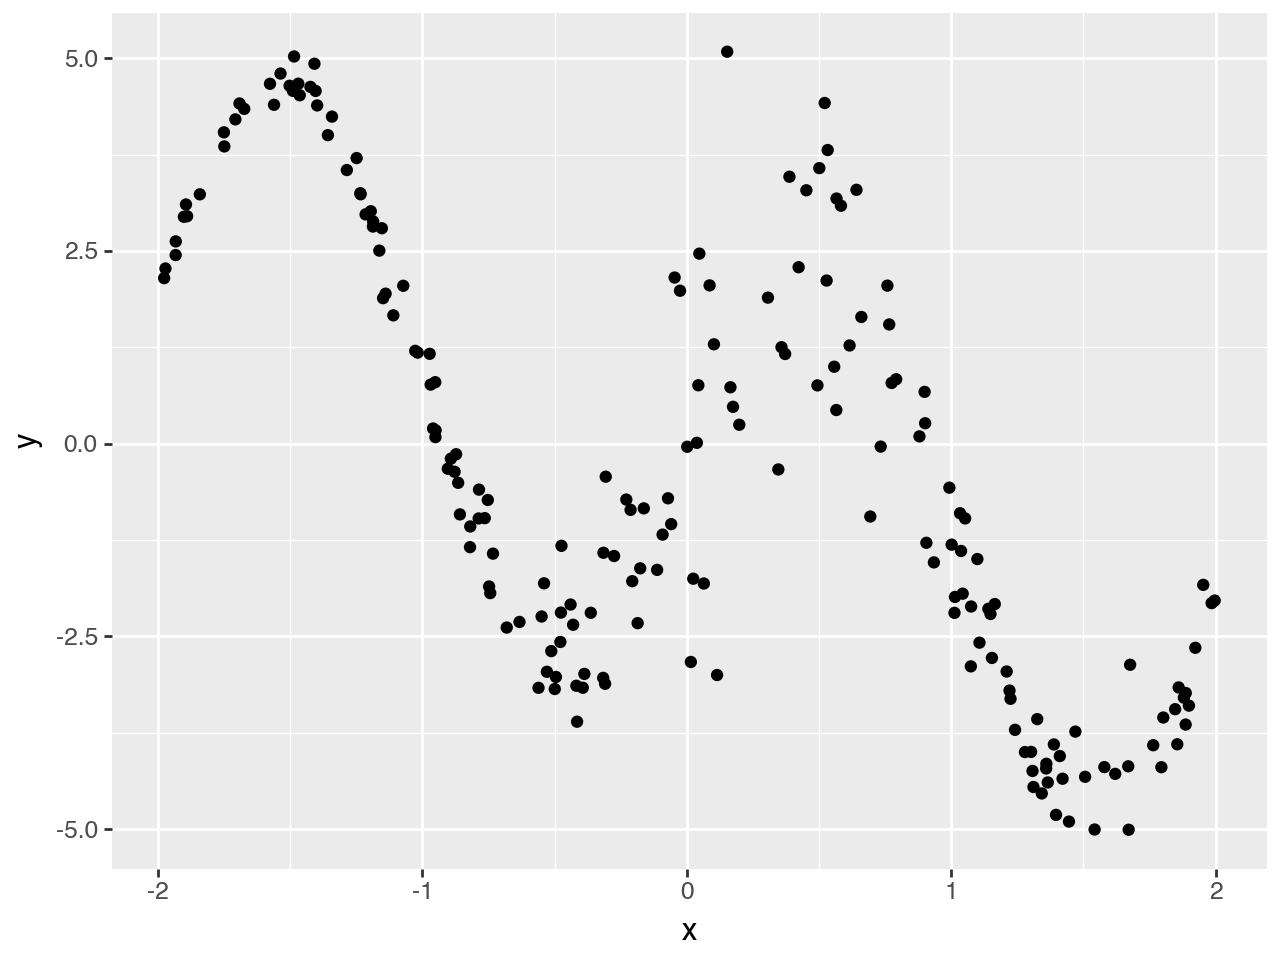

In [3]:
(p9.ggplot(df) + p9.geom_point(p9.aes("x", "y")))

## Model Definition

### Setup response model

In [4]:
loc = gam.AdditivePredictor("loc")
scale = gam.AdditivePredictor("scale", inv_link=jnp.exp)


y = lsl.Var.new_obs(
    value=df.y.to_numpy(),
    distribution=lsl.Dist(tfd.Normal, loc=loc, scale=scale),
    name="y",
)


registry = gam.PandasRegistry(df)
tbl = gam.TermBuilder(registry, prefix_names_by="loc.")
tbs = gam.TermBuilder(registry, prefix_names_by="scale.")

loc_ps = tbl.ps("x", k=20)
scale_ps = tbs.ps("x", k=20)

loc += loc_ps
scale += scale_ps


### Build model and configure IWLS proposals

This version configures the general `IWLSProposal` explicitly with deterministic
score-squared working weights. The weights differentiate the model log likelihood
with respect to each predictor's linear predictor. For production code, the bulk
helper `IWLSProposal.set_mcmc_specs()` can assign this pattern to all supported
structured terms in a predictor.


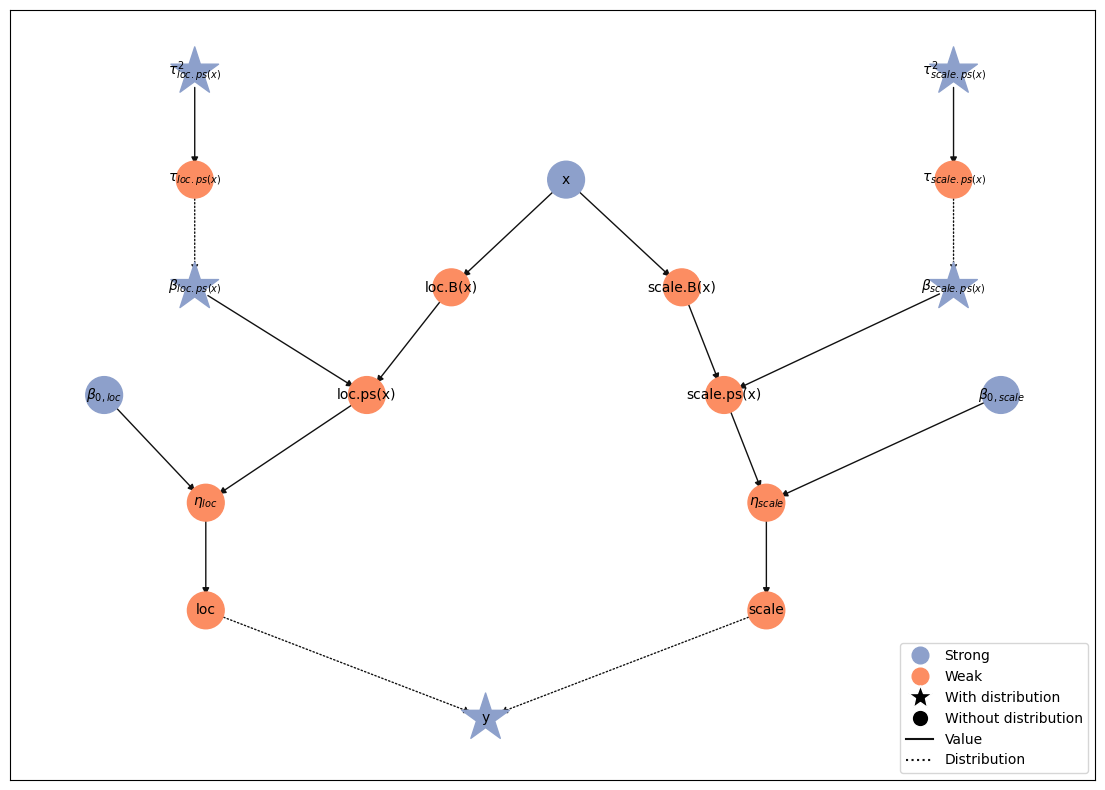

In [5]:
model = lsl.Model([y])

loc_weights = IWLSWeights.score_squared(loc.linear_predictor.name)
scale_weights = IWLSWeights.score_squared(scale.linear_predictor.name)

# Bulk alternative:
# IWLSProposal.set_mcmc_specs(loc, loc_weights, fallback_chol_info=None)
# IWLSProposal.set_mcmc_specs(scale, scale_weights, fallback_chol_info=None)
loc_iwls = IWLSProposal.from_term(loc_ps, loc_weights)
scale_iwls = IWLSProposal.from_term(scale_ps, scale_weights)

loc_ps.coef.inference = gs.MCMCSpec(
    kernel=loc_iwls.kernel_factory(),
    kernel_kwargs={"fallback_chol_info": None},
)
scale_ps.coef.inference = gs.MCMCSpec(
    kernel=scale_iwls.kernel_factory(),
    kernel_kwargs={"fallback_chol_info": None},
)

model.plot_vars()


## Run MCMC

In [6]:
eb = gs.LieselMCMC(model).get_engine_builder(seed=1, num_chains=4)

eb.add_adaptation(3000)
eb.add_posterior(10_000, thinning=10)

engine = eb.build()
engine.sample_all_epochs()
results = engine.get_results()

liesel.goose.builder - WARNING - No jitter functions provided for position keys '$\\beta_{loc.ps(x)}$', '$\\beta_{scale.ps(x)}$', '$\\tau_{loc.ps(x)}^2$', '$\\beta_{0,loc}$', '$\\tau_{scale.ps(x)}^2$', '$\\beta_{0,scale}$'. The initial values for these keys won't be jittered
liesel.goose.engine - INFO - Initializing kernels...
liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 300 transitions, 25 jitted together
100%|████████████████████████████████████████| 12/12 [00:02<00:00,  4.22chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|████████████████████████████████████████| 1/1 [00:00<00:00, 1058.37chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 50 transitions, 25 jitted together
100%|████████████████████████████████████████| 2/2 [00:00<00:00, 1736.05chunk/s]
liesel.goose.e

### MCMC summary

In [7]:
summary = gs.Summary(results)
summary

Parameter summary:

                                 kernel      mean        sd    q_0.05  \
parameter              index                                            
$\beta_{0,loc}$        ()     kernel_03 -0.326186  0.061379 -0.429025   
$\beta_{0,scale}$      ()     kernel_05 -0.627090  0.053144 -0.713342   
$\beta_{loc.ps(x)}$    (0,)   kernel_00  0.155218  0.327715 -0.371608   
                       (1,)   kernel_00 -0.150256  0.291156 -0.627018   
                       (2,)   kernel_00  0.128637  0.291099 -0.349562   
                       (3,)   kernel_00  0.136265  0.286973 -0.328117   
                       (4,)   kernel_00 -0.261948  0.277427 -0.724038   
                       (5,)   kernel_00  0.026509  0.264021 -0.399466   
                       (6,)   kernel_00  0.010650  0.247745 -0.400843   
                       (7,)   kernel_00  0.117542  0.225011 -0.238698   
                       (8,)   kernel_00  0.068127  0.215293 -0.275078   
                       (9,)   kernel_00  0.076049  0.181087 -0.210038   
                       (10,)  kernel_00  0.086874  0.166126 -0.188828   
                       (11,)  kernel_00 -0.041604  0.138551 -0.268676   
                       (12,)  kernel_00  0.075088  0.111942 -0.105973   
                       (13,)  kernel_00 -0.082344  0.086493 -0.220506   
                       (14,)  kernel_00  1.229699  0.063750  1.124173   
                       (15,)  kernel_00  0.021370  0.042317 -0.049383   
                       (16,)  kernel_00 -0.015260  0.021189 -0.049072   
                       (17,)  kernel_00  0.009871  0.008874 -0.004600   
                       (18,)  kernel_00 -0.423860  0.030927 -0.474568   
$\beta_{scale.ps(x)}$  (0,)   kernel_01  0.011351  0.077749 -0.109447   
                       (1,)   kernel_01 -0.009457  0.077446 -0.133850   
                       (2,)   kernel_01 -0.011443  0.075037 -0.134243   
                       (3,)   kernel_01 -0.005864  0.073478 -0.127740   
                       (4,)   kernel_01  0.003435  0.074580 -0.120301   
                       (5,)   kernel_01 -0.006584  0.078316 -0.139290   
                       (6,)   kernel_01  0.025388  0.074973 -0.086325   
                       (7,)   kernel_01  0.032726  0.071412 -0.078360   
                       (8,)   kernel_01  0.012470  0.071241 -0.101913   
                       (9,)   kernel_01 -0.014023  0.067612 -0.128582   
                       (10,)  kernel_01  0.012818  0.068362 -0.097405   
                       (11,)  kernel_01  0.007482  0.064682 -0.094651   
                       (12,)  kernel_01  0.066961  0.060959 -0.023865   
                       (13,)  kernel_01 -0.066304  0.051828 -0.154681   
                       (14,)  kernel_01  0.059346  0.041893 -0.009579   
                       (15,)  kernel_01  0.080102  0.029458  0.032230   
                       (16,)  kernel_01  0.004749  0.016869 -0.022881   
                       (17,)  kernel_01 -0.041794  0.007105 -0.053164   
                       (18,)  kernel_01  0.129437  0.027372  0.084691   
$\tau_{loc.ps(x)}^2$   ()     kernel_02  0.138614  0.061311  0.068785   
$\tau_{scale.ps(x)}^2$ ()     kernel_04  0.005878  0.004024  0.001982   

                                 q_0.5    q_0.95  sample_size     ess_bulk  \
parameter              index                                                 
$\beta_{0,loc}$        ()    -0.326660 -0.226266         4000    59.186380   
$\beta_{0,scale}$      ()    -0.627045 -0.540138         4000  2820.255398   
$\beta_{loc.ps(x)}$    (0,)   0.150510  0.694396         4000  1178.603927   
                       (1,)  -0.143068  0.311879         4000   993.920726   
                       (2,)   0.127813  0.598248         4000  1131.998635   
                       (3,)   0.136054  0.603851         4000  1034.151256   
                       (4,)  -0.255195  0.183585         4000  1066.044481   
                       (5,)   0.024174  0.460338         4000   9

### MCMC trace plots

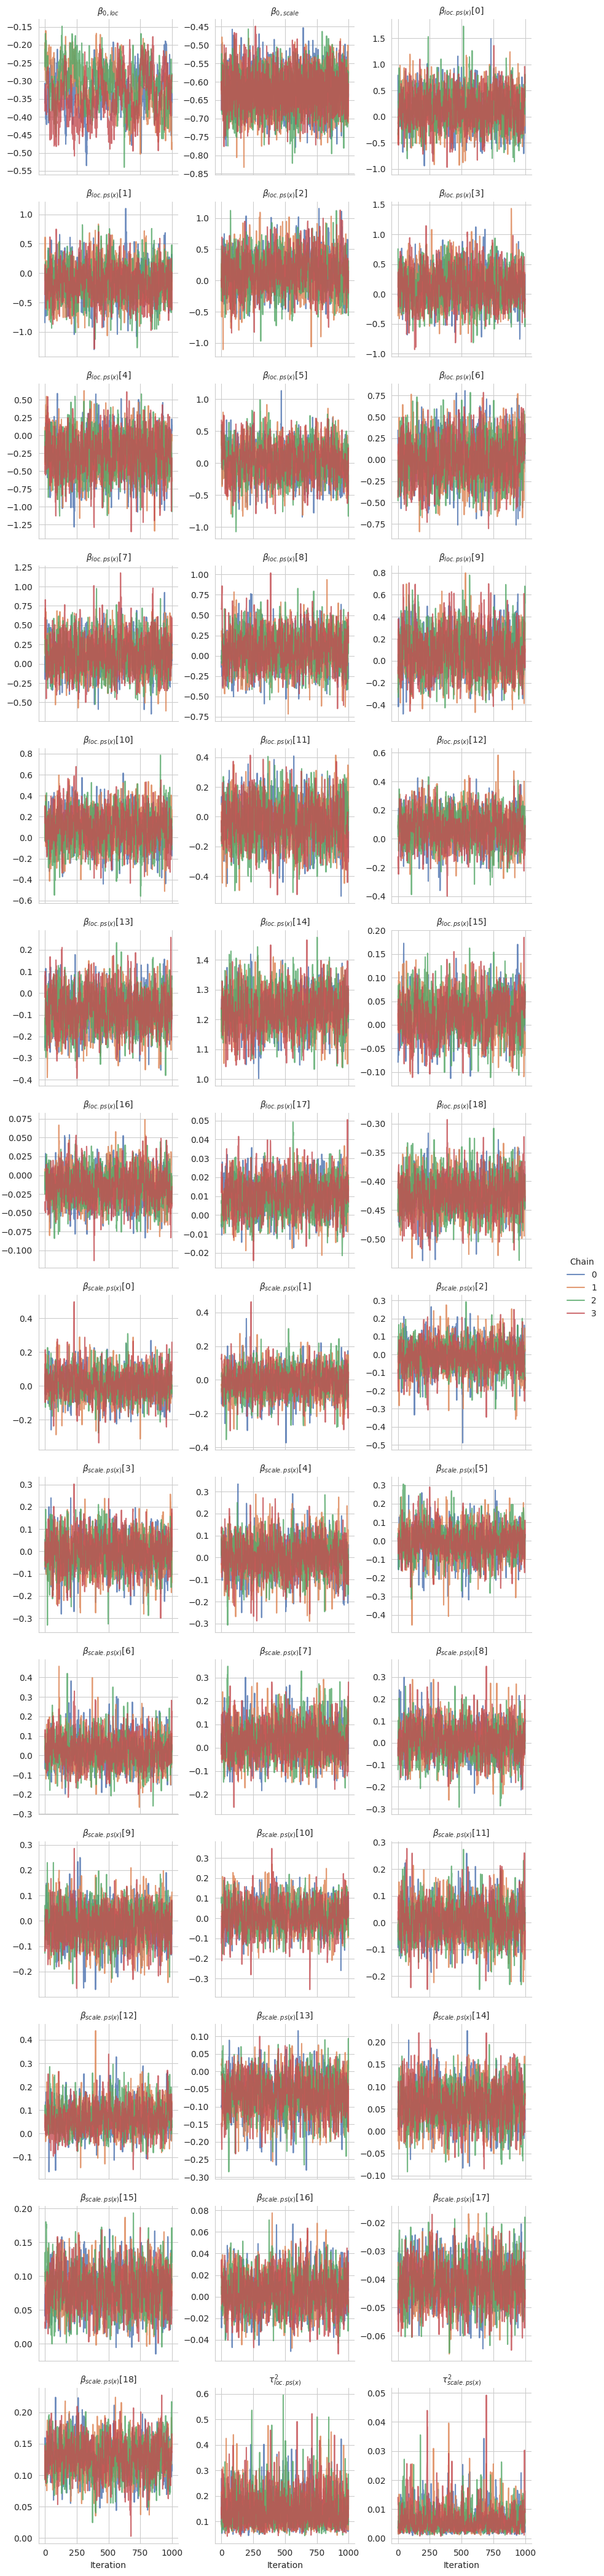

In [8]:
gs.plot_trace(results)

## Predictions

In [9]:
samples = results.get_posterior_samples()

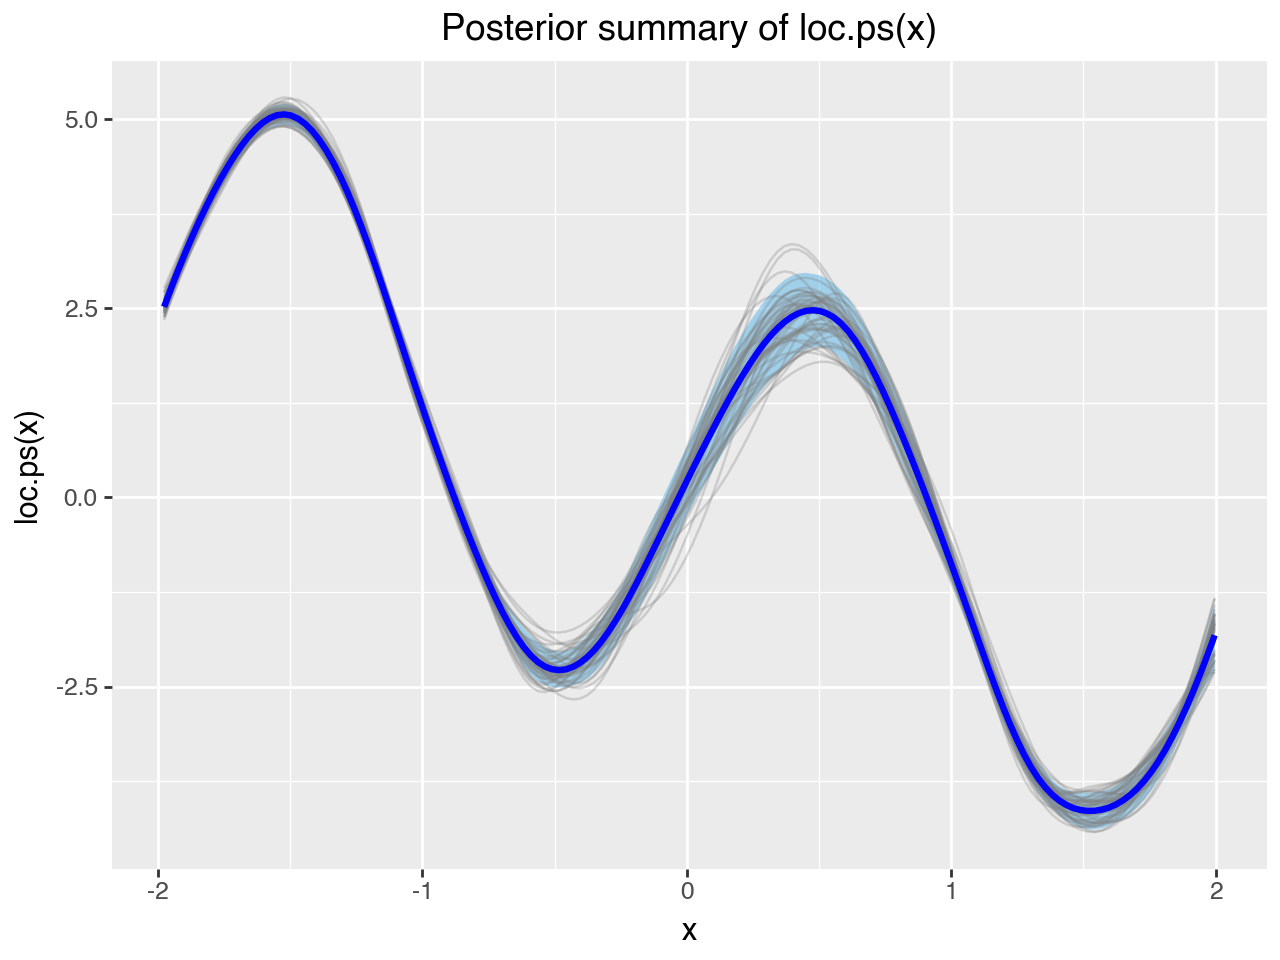

In [10]:
gam.plot_1d_smooth(term=model.vars["loc.ps(x)"], samples=samples)

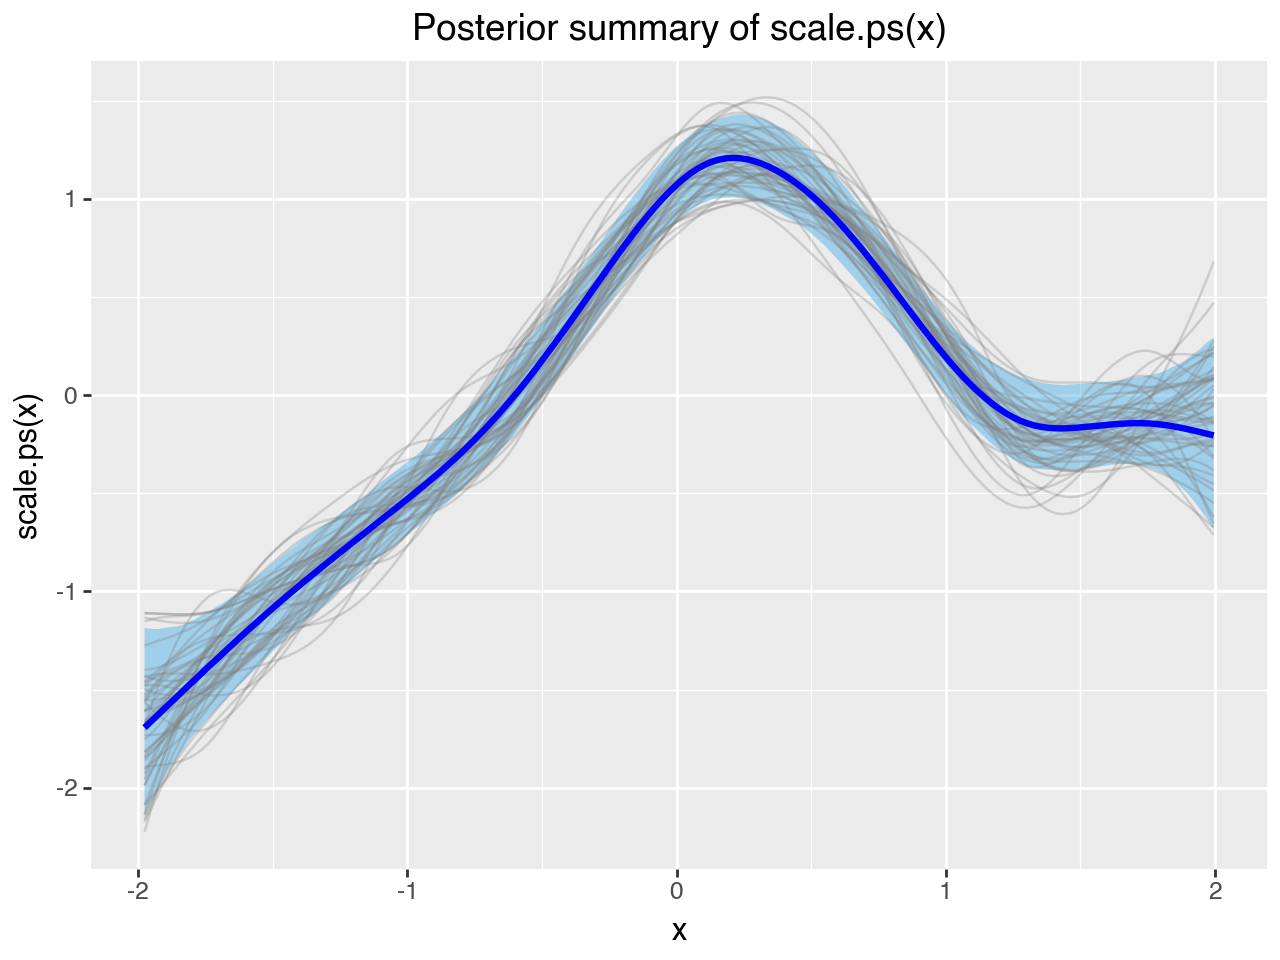

In [11]:
gam.plot_1d_smooth(term=model.vars["scale.ps(x)"], samples=samples)

### Predict variables at new x values

In [12]:
x_grid = jnp.linspace(df.x.min(), df.x.max(), 300)

predictions = model.predict(
    samples=samples,
    predict=["loc.ps(x)", "scale.ps(x)", "loc", "scale"],
    newdata={"x": x_grid},
)

predictions_summary = gs.SamplesSummary(predictions).to_dataframe().reset_index()
predictions_summary["x"] = np.tile(x_grid, len(predictions))

### Plot parameters as functions of covariate

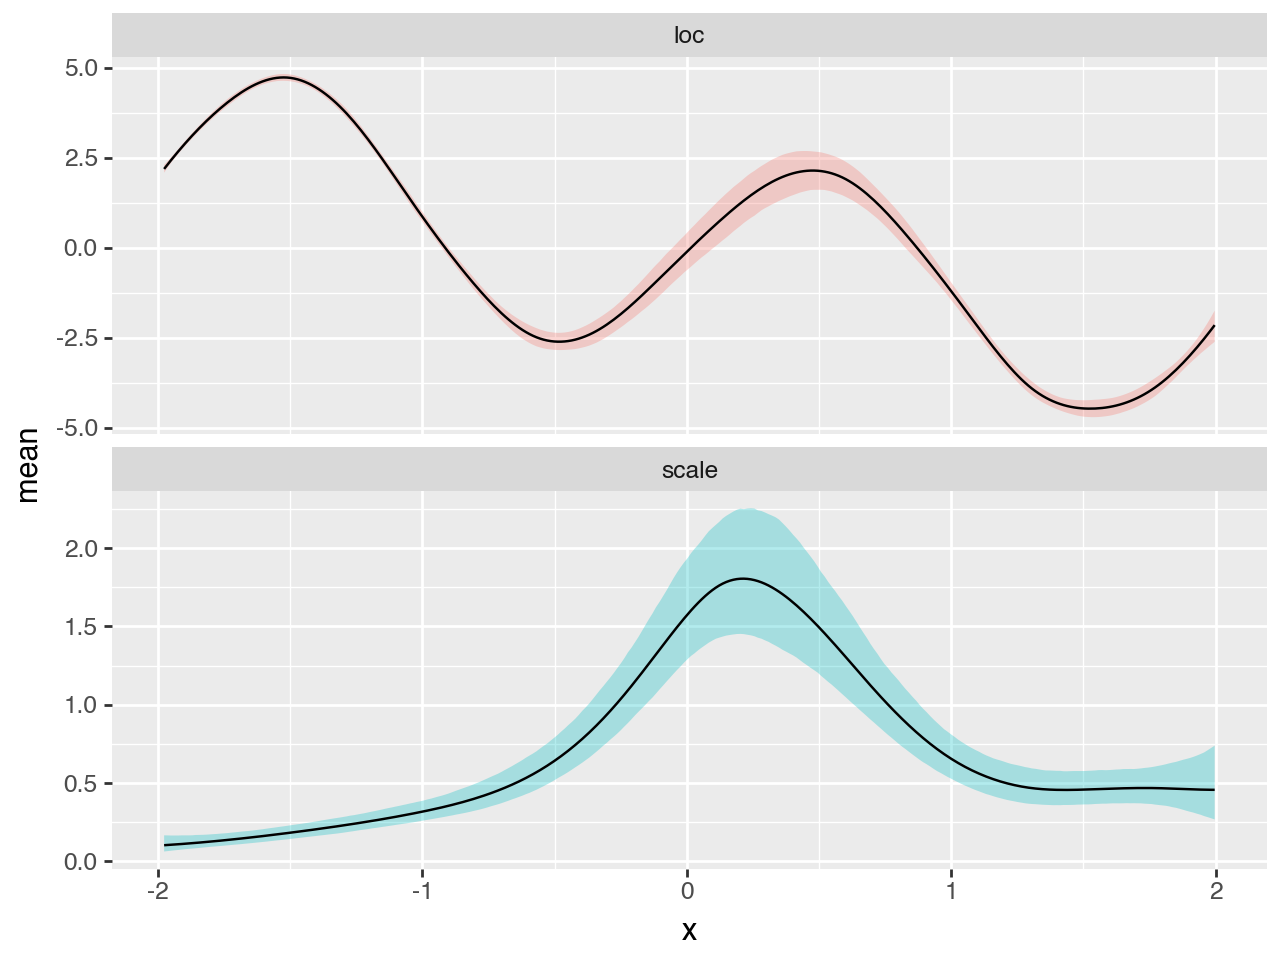

In [13]:
select = predictions_summary["variable"].isin(["loc", "scale"])
(
    p9.ggplot(predictions_summary[select])
    + p9.geom_ribbon(
        p9.aes("x", ymin="q_0.05", ymax="q_0.95", fill="variable"), alpha=0.3
    )
    + p9.geom_line(p9.aes("x", "mean"))
    + p9.facet_wrap("~variable", scales="free_y", ncol=1)
    + p9.guides(fill="none")
)

### Plot fitted location with raw data

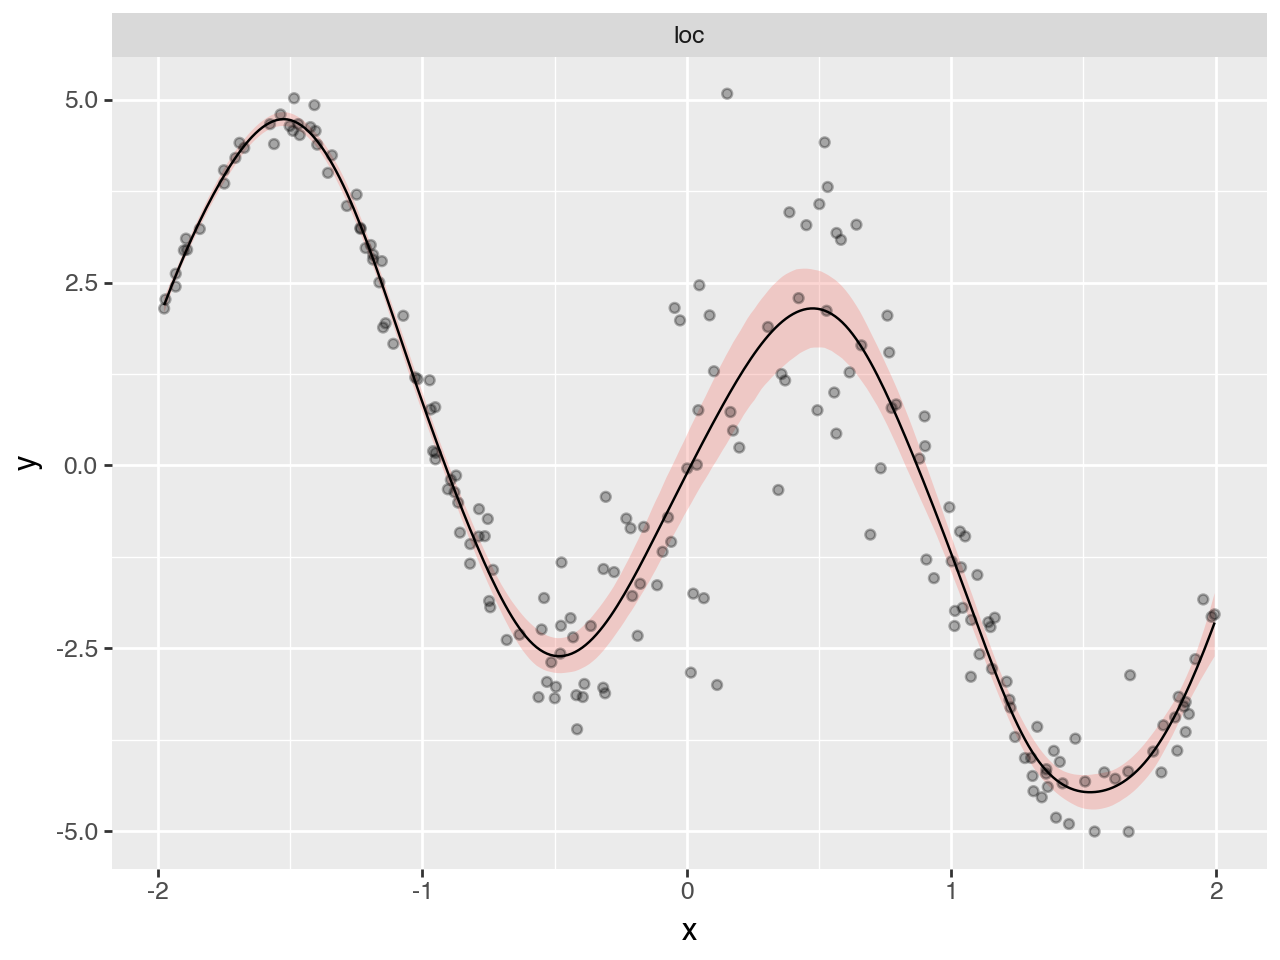

In [14]:
select = predictions_summary["variable"].isin(["loc"])
(
    p9.ggplot(predictions_summary[select])
    + p9.geom_ribbon(
        p9.aes("x", ymin="q_0.05", ymax="q_0.95", fill="variable"), alpha=0.3
    )
    + p9.geom_point(p9.aes("x", "y"), data=df, alpha=0.3)
    + p9.geom_line(p9.aes("x", "mean"))
    + p9.facet_wrap("~variable", scales="free_y", ncol=1)
    + p9.guides(fill="none")
)

### Posterior predictive distribution

In [15]:
select = predictions_summary["variable"].isin(["loc", "scale"])
mu_sigma_df = (
    predictions_summary[select][["variable", "mean", "x"]]
    .pivot(index="x", columns=["variable"], values="mean")
    .reset_index()
)

mu_sigma_df["low"] = mu_sigma_df["loc"] - mu_sigma_df["scale"]
mu_sigma_df["high"] = mu_sigma_df["loc"] + mu_sigma_df["scale"]
mu_sigma_df

variable,x,loc,scale,low,high
0,-1.976702,2.193085,0.102754,2.090331,2.295840
1,-1.963415,2.318082,0.104197,2.213885,2.422278
2,-1.950128,2.440546,0.105692,2.334854,2.546238
3,-1.936841,2.560439,0.107239,2.453200,2.667678
4,-1.923554,2.677754,0.108838,2.568916,2.786591
...,...,...,...,...,...
295,1.942956,-2.644590,0.457869,-3.102458,-2.186721
296,1.956243,-2.524600,0.457342,-2.981942,-2.067258
297,1.969530,-2.401598,0.456935,-2.858533,-1.944664
298,1.982817,-2.275700,0.456667,-2.732367,-1.819033


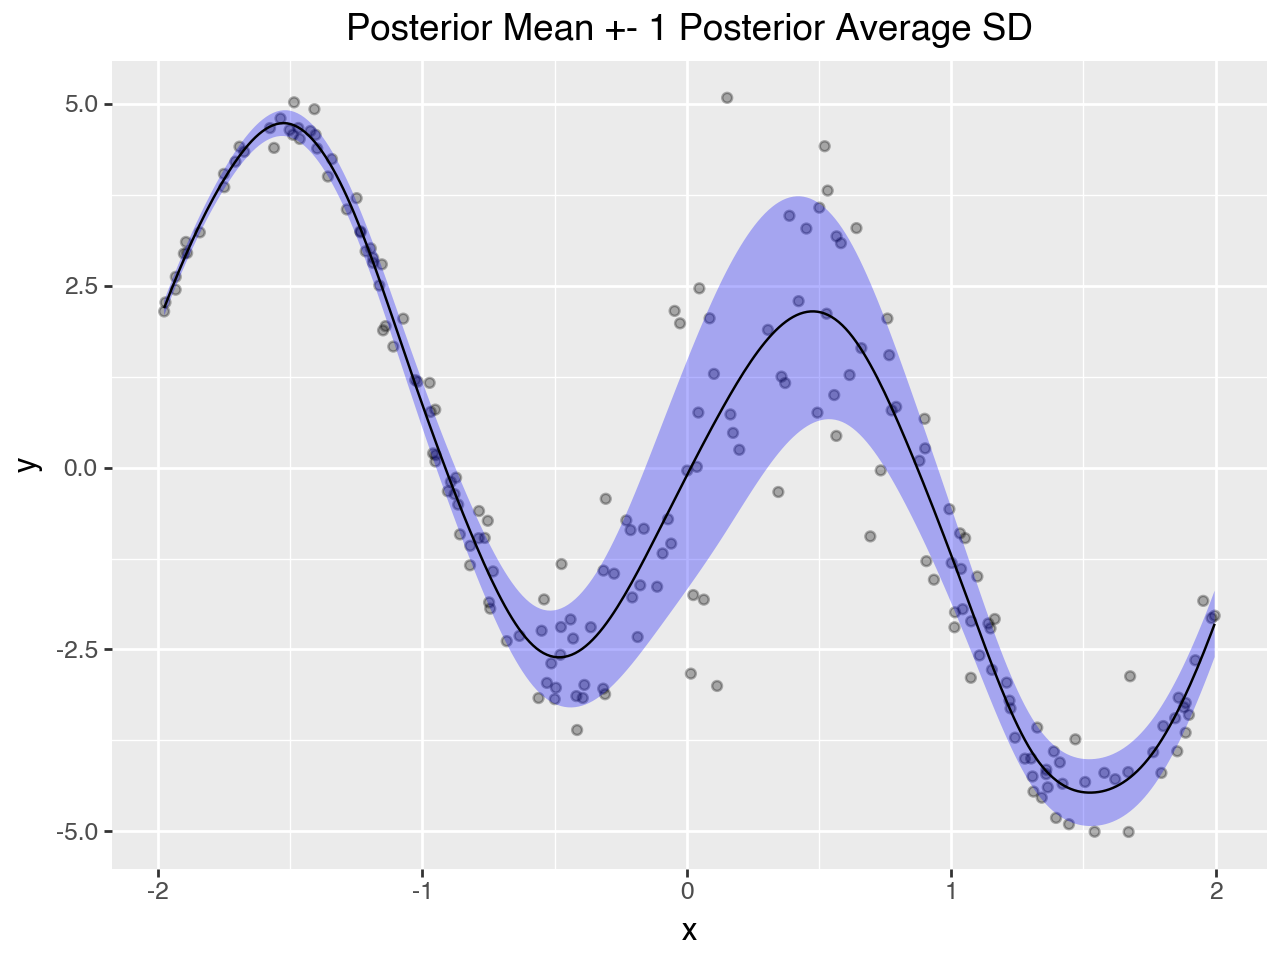

In [16]:
(
    p9.ggplot()
    + p9.geom_point(p9.aes("x", "y"), data=df, alpha=0.3)
    + p9.geom_ribbon(
        p9.aes("x", ymin="low", ymax="high"),
        alpha=0.3,
        fill="blue",
        data=mu_sigma_df,
    )
    + p9.geom_line(p9.aes("x", "loc"), data=mu_sigma_df)
    + p9.labs(title="Posterior Mean +- 1 Posterior Average SD")
    + p9.guides(fill="none")
)

### Sample from posterior predictive distribution

In [17]:
import jax

ppsamples = model.sample(shape=(), seed=jax.random.key(1), posterior_samples=samples)

ppsamples["y"].shape

(4, 1000, 200)

In [18]:
# summarise ppsamples
ppsamples_summary = gs.SamplesSummary(ppsamples).to_dataframe().reset_index()

# add covariate to df
ppsamples_summary["x"] = df["x"].to_numpy()

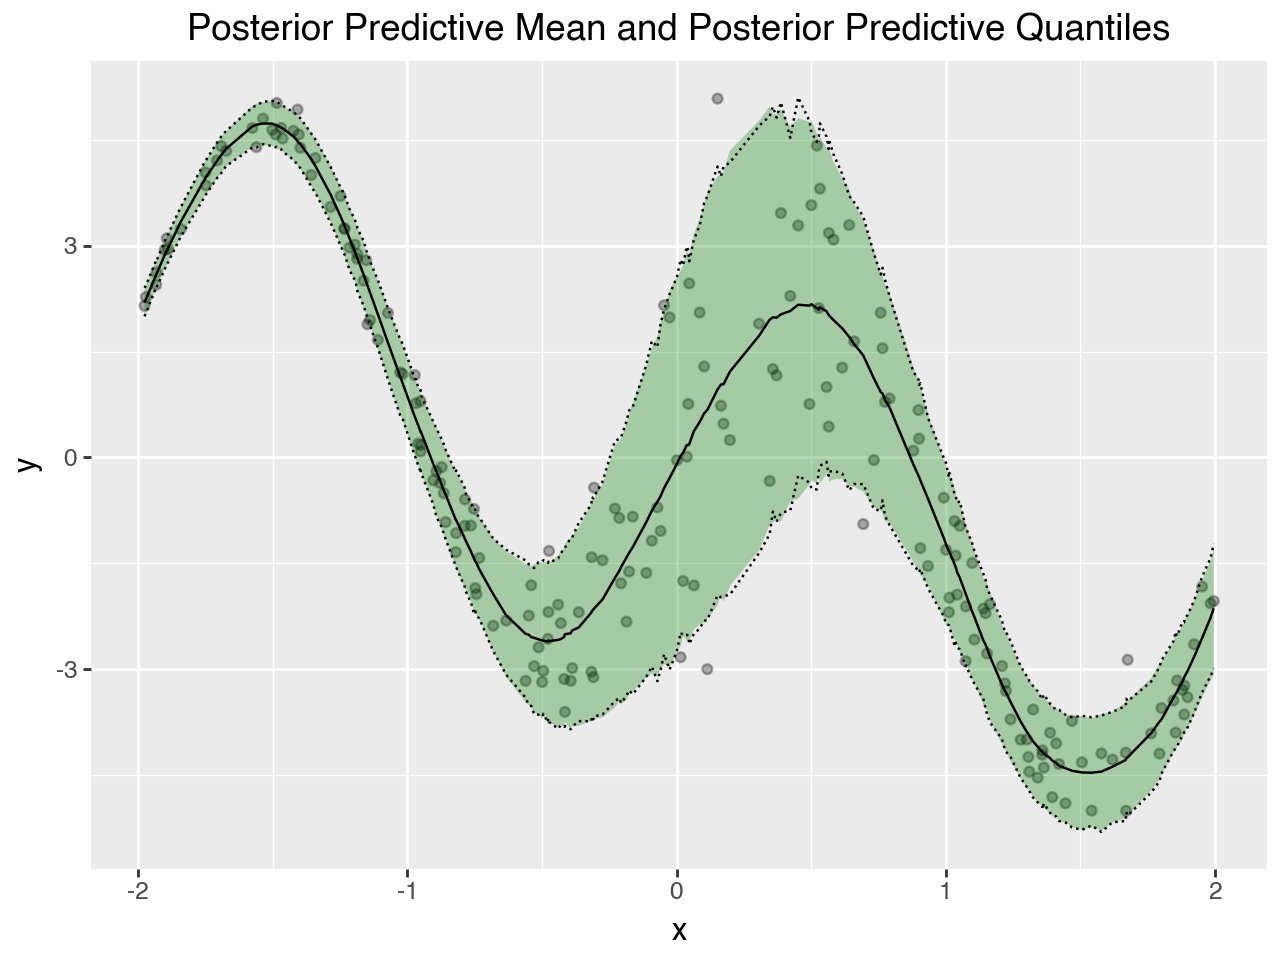

In [19]:
(
    p9.ggplot(ppsamples_summary)
    + p9.geom_point(p9.aes("x", "y"), data=df, alpha=0.3)
    + p9.geom_ribbon(
        p9.aes("x", ymin="q_0.05", ymax="q_0.95"),
        alpha=0.3,
        fill="green",
    )
    + p9.geom_line(p9.aes("x", "hdi_low"), linetype="dotted")
    + p9.geom_line(p9.aes("x", "hdi_high"), linetype="dotted")
    + p9.geom_line(p9.aes("x", "mean"))
    + p9.labs(title="Posterior Predictive Mean and Posterior Predictive Quantiles")
    + p9.guides(fill="none")
)